KABILASH S
E0323036

# Experiment 3 — Vision Transformer for Image Captioning

## Aim
To build an image-captioning pipeline using a pretrained Vision Transformer (ViT) as the visual encoder and a trainable autoregressive Transformer decoder.

## Objectives

1. Load a manageable Flickr8k subset programmatically with no credentials.
2. Explain and use ViT patch embeddings, positional embeddings, and Transformer encoding.
3. Train a causal caption decoder over frozen visual features.
4. Evaluate with validation loss, corpus BLEU, images, references, and generated captions.



## Dataset

```text
Dataset: Flickr8k Captions With Splits
Dataset source: Hugging Face Datasets — intro/flickr8k (original Flickr8k)
Task: English image caption generation
Number of samples: 8,000 images, each with five captions
Training samples: CONFIG["train_images"] images (five caption pairs per image)
Validation samples: CONFIG["val_images"] images
Test samples: CONFIG["test_images"] images
Input format: RGB image
Output format: Autoregressively generated English caption
```

The dataset is streamed so a lab run need not store the full ~1.1 GB corpus in the project. Official train/dev/test splits remain disjoint. Images are resized/cropped to 224×224 and ImageNet-normalized using the transforms attached to the pretrained ViT weights. Captions are lower-cased, tokenized, truncated, and numericalized from training captions only.

##  Required libraries and configuration

In [ ]:
import math, os, random, re, time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

from itertools import islice
from nltk.translate.bleu_score import SmoothingFunction, corpus_bleu
from torchvision.models import ViT_B_16_Weights, vit_b_16

CONFIG = {
    "train_images": 300, "val_images": 60, "test_images": 60,
    "feature_batch_size": 16, "batch_size": 64, "learning_rate": 2e-3,
    "epochs": 4, "embedding_dim": 192, "hidden_dim": 384,
    "attention_heads": 6, "decoder_layers": 2, "max_sequence_length": 24,
    "min_frequency": 2,
}
CONFIG

Using device: cuda


{'train_images': 300,
 'val_images': 60,
 'test_images': 60,
 'feature_batch_size': 16,
 'batch_size': 64,
 'learning_rate': 0.002,
 'epochs': 4,
 'embedding_dim': 192,
 'hidden_dim': 384,
 'attention_heads': 6,
 'decoder_layers': 2,
 'max_sequence_length': 24,
 'min_frequency': 2}

##  Load, explore, and preprocess Flickr8k

Resolving data files:   0%|          | 0/6001 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1001 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1001 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/6001 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1001 [00:00<?, ?it/s]

...

Resolving data files:   0%|          | 0/1001 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/6001 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1001 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1001 [00:00<?, ?it/s]

,split,images_used,captions_available
0,train,300,1500
1,validation,60,300
2,test,60,300


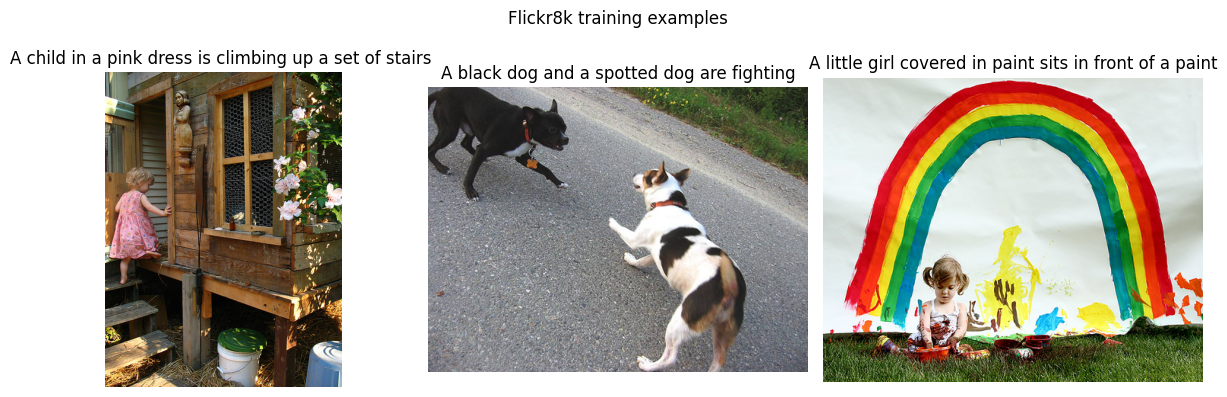

In [ ]:
def take_stream(split, count):
    stream = load_dataset("intro/flickr8k", split=split, streaming=True)
    return list(islice(stream, count))

train_rows = take_stream("train", CONFIG["train_images"])
val_rows = take_stream("dev", CONFIG["val_images"])
test_rows = take_stream("test", CONFIG["test_images"])
display(pd.DataFrame({"split": ["train", "validation", "test"],
                      "images_used": list(map(len, [train_rows, val_rows, test_rows])),
                      "captions_available": [5*len(train_rows), 5*len(val_rows), 5*len(test_rows)]}))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, row in zip(axes, train_rows[:3]):
    ax.imshow(row["image"].convert("RGB")); ax.axis("off"); ax.set_title(row["caption_0"][:55])
plt.suptitle("Flickr8k training examples"); plt.tight_layout(); plt.show()

## Caption vocabulary

In [ ]:
TOKEN_PATTERN = re.compile(r"[A-Za-zÀ-ÿ']+|[.!?,;:]")

def tokenize(text):
    """Lower-case word/punctuation tokenizer requiring no external model."""
    return TOKEN_PATTERN.findall(text.lower())

class Vocabulary:
    def __init__(self, texts, min_freq=2, specials=("<pad>", "<unk>", "<bos>", "<eos>")):
        counts = Counter(token for text in texts for token in tokenize(text))
        self.itos = list(specials) + sorted(w for w, n in counts.items() if n >= min_freq and w not in specials)
        self.stoi = {word: index for index, word in enumerate(self.itos)}
        self.pad_idx = self.stoi["<pad>"]
        self.unk_idx = self.stoi["<unk>"]
        self.bos_idx = self.stoi["<bos>"]
        self.eos_idx = self.stoi["<eos>"]

    def __len__(self):
        return len(self.itos)

    def encode(self, text, max_length, add_boundaries=True):
        tokens = tokenize(text)
        if add_boundaries:
            tokens = ["<bos>"] + tokens[: max_length - 2] + ["<eos>"]
        else:
            tokens = tokens[:max_length]
        return [self.stoi.get(token, self.unk_idx) for token in tokens]

    def decode(self, ids):
        ignored = {self.pad_idx, self.bos_idx, self.eos_idx}
        return " ".join(self.itos[i] for i in ids if i not in ignored)

caption_fields = [f"caption_{i}" for i in range(5)]
training_captions = [row[field] for row in train_rows for field in caption_fields]
vocab = Vocabulary(training_captions, min_freq=CONFIG["min_frequency"])
print(f"Caption vocabulary: {len(vocab):,} tokens; training caption pairs: {len(training_captions):,}")

Caption vocabulary: 872 tokens; training caption pairs: 1,500


##  Vision Transformer encoder and caption decoder

A 224×224 image is divided into 16×16 patches (196 patches). Each flattened patch is linearly projected, a learned class token is prepended, and learned positional embeddings preserve spatial order. Multi-head self-attention and feed-forward blocks transform this sequence. We use the pretrained `torchvision` ViT-B/16 **class-token representation** (768 values) as a frozen, reusable visual memory vector.

The decoder embeds the caption prefix, adds learned positional embeddings, applies masked self-attention so position $t$ cannot see future words, then cross-attends to the projected ViT feature. Its linear head predicts the next token. Training uses shifted ground-truth captions; generation feeds predictions back autoregressively. Freezing/caching ViT features makes this demonstration practical while still using a real ViT visual encoder.

In [ ]:
weights = ViT_B_16_Weights.DEFAULT
image_transform = weights.transforms()
vit = vit_b_16(weights=weights).to(DEVICE).eval()
for parameter in vit.parameters(): parameter.requires_grad = False

@torch.no_grad()
def encode_images(rows):
    """Run the actual ViT patch projection + Transformer encoder once per image."""
    features = []
    for start in tqdm(range(0, len(rows), CONFIG["feature_batch_size"]), desc="ViT features"):
        batch = torch.stack([image_transform(row["image"].convert("RGB"))
                             for row in rows[start:start+CONFIG["feature_batch_size"]]]).to(DEVICE)
        patches = vit._process_input(batch)
        class_tokens = vit.class_token.expand(batch.size(0), -1, -1)
        encoded_tokens = vit.encoder(torch.cat([class_tokens, patches], dim=1))
        features.append(encoded_tokens[:, 0].cpu())
    return torch.cat(features)

train_features = encode_images(train_rows)
val_features = encode_images(val_rows)
test_features = encode_images(test_rows)
print("Cached feature shapes:", train_features.shape, val_features.shape, test_features.shape)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /home/kabilash01/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


  0%|          | 0.00/330M [00:00<?, ?B/s]

  0%|          | 128k/330M [00:00<09:26, 611kB/s]

  0%|          | 384k/330M [00:00<05:00, 1.15MB/s]

  0%|          | 512k/330M [00:00<04:52, 1.18MB/s]

...

100%|██████████| 330M/330M [04:22<00:00, 1.32MB/s]

ViT features:   0%|          | 0/19 [00:00<?, ?it/s]

ViT features:   0%|          | 0/4 [00:00<?, ?it/s]

ViT features:   0%|          | 0/4 [00:00<?, ?it/s]

Cached feature shapes: torch.Size([300, 768]) torch.Size([60, 768]) torch.Size([60, 768])


In [ ]:
class CaptionPairs(Dataset):
    def __init__(self, rows, features, use_all_captions):
        self.rows, self.features = rows, features
        self.keys = [(i, j) for i in range(len(rows)) for j in (range(5) if use_all_captions else range(1))]
    def __len__(self): return len(self.keys)
    def __getitem__(self, index):
        image_index, caption_index = self.keys[index]
        caption = self.rows[image_index][f"caption_{caption_index}"]
        return self.features[image_index], torch.tensor(vocab.encode(caption, CONFIG["max_sequence_length"]))

def collate_captions(batch):
    features, captions = zip(*batch)
    return torch.stack(features), nn.utils.rnn.pad_sequence(captions, batch_first=True, padding_value=vocab.pad_idx)

train_loader = DataLoader(CaptionPairs(train_rows, train_features, True), batch_size=CONFIG["batch_size"],
                          shuffle=True, collate_fn=collate_captions, generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(CaptionPairs(val_rows, val_features, False), batch_size=CONFIG["batch_size"], collate_fn=collate_captions)

class TransformerCaptionDecoder(nn.Module):
    def __init__(self):
        super().__init__(); d = CONFIG["embedding_dim"]
        self.visual_projection = nn.Linear(768, d)
        self.token_embedding = nn.Embedding(len(vocab), d, padding_idx=vocab.pad_idx)
        self.position = nn.Parameter(torch.zeros(1, CONFIG["max_sequence_length"], d))
        layer = nn.TransformerDecoderLayer(d, CONFIG["attention_heads"], CONFIG["hidden_dim"], dropout=.2, batch_first=True)
        self.decoder = nn.TransformerDecoder(layer, CONFIG["decoder_layers"])
        self.output = nn.Linear(d, len(vocab))
    def forward(self, visual_features, caption_prefix):
        length = caption_prefix.size(1)
        memory = self.visual_projection(visual_features).unsqueeze(1)
        target = self.token_embedding(caption_prefix) * math.sqrt(CONFIG["embedding_dim"]) + self.position[:, :length]
        causal_mask = nn.Transformer.generate_square_subsequent_mask(length, device=caption_prefix.device)
        decoded = self.decoder(target, memory, tgt_mask=causal_mask,
                               tgt_key_padding_mask=caption_prefix.eq(vocab.pad_idx))
        return self.output(decoded)

model = TransformerCaptionDecoder().to(DEVICE)
print(model)
print(f"Trainable decoder parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

TransformerCaptionDecoder(
  (visual_projection): Linear(in_features=768, out_features=192, bias=True)
  (token_embedding): Embedding(872, 192, padding_idx=0)
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_features=192, bias=True)
        )
        (multihead_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_features=192, bias=True)
        )
        (linear1): Linear(in_features=192, out_features=384, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=384, out_features=192, bias=True)
        (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm3): LayerNorm((192,), eps=1e-05, elementwise_affine=True, bias=

## 11–12. Decoder training and validation

/home/kabilash01/miniconda3/envs/dl/lib/python3.10/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


Epoch 01 | train 4.5363 | validation 3.4807 | 0.3s
Epoch 02 | train 3.3926 | validation 3.1941 | 0.1s


Epoch 03 | train 2.8896 | validation 3.0824 | 0.1s
Epoch 04 | train 2.5397 | validation 3.0611 | 0.1s


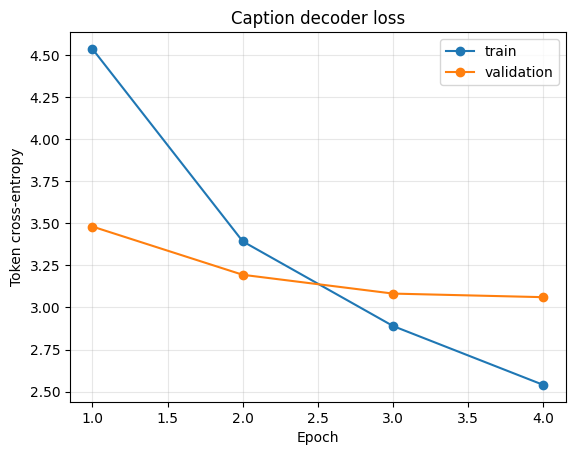

In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=vocab.pad_idx)
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"])

def caption_loss(loader, training):
    model.train(training); total, tokens = 0.0, 0
    for features, captions in loader:
        features, captions = features.to(DEVICE), captions.to(DEVICE)
        prefix, gold = captions[:, :-1], captions[:, 1:]
        if training: optimizer.zero_grad()
        with torch.set_grad_enabled(training):
            logits = model(features, prefix)
            loss = criterion(logits.reshape(-1, len(vocab)), gold.reshape(-1))
            if training:
                loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()
        count = gold.ne(vocab.pad_idx).sum().item(); total += loss.item()*count; tokens += count
    return total/tokens

history = {"train_loss": [], "val_loss": []}; best_state, best_loss = None, float("inf")
for epoch in range(1, CONFIG["epochs"]+1):
    started=time.time(); train_loss=caption_loss(train_loader, True); val_loss=caption_loss(val_loader, False)
    history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
    if val_loss < best_loss:
        best_loss=val_loss; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    print(f"Epoch {epoch:02d} | train {train_loss:.4f} | validation {val_loss:.4f} | {time.time()-started:.1f}s")
model.load_state_dict(best_state)

plt.plot(range(1, CONFIG["epochs"]+1), history["train_loss"], marker="o", label="train")
plt.plot(range(1, CONFIG["epochs"]+1), history["val_loss"], marker="o", label="validation")
plt.xlabel("Epoch"); plt.ylabel("Token cross-entropy"); plt.title("Caption decoder loss"); plt.grid(alpha=.3); plt.legend(); plt.show()

##  BLEU evaluation and qualitative predictions

Corpus BLEU on 60 test images: 0.0677


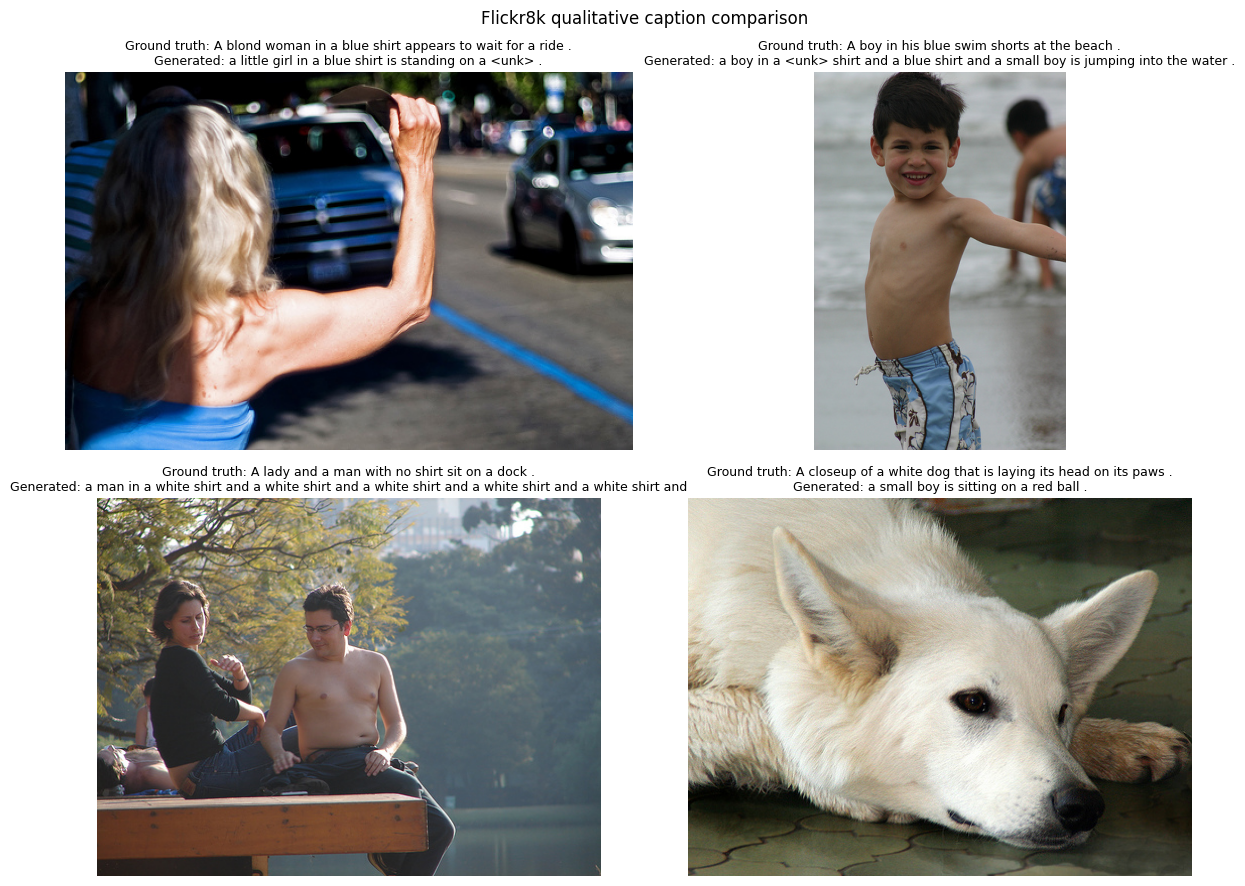

In [ ]:
@torch.no_grad()
def generate_caption(feature):
    model.eval(); generated = [vocab.bos_idx]
    for _ in range(CONFIG["max_sequence_length"]-1):
        prefix = torch.tensor(generated, device=DEVICE).unsqueeze(0)
        logits = model(feature.to(DEVICE).unsqueeze(0), prefix)
        next_id = logits[0, -1].argmax().item()
        if next_id == vocab.eos_idx: break
        generated.append(next_id)
    return vocab.decode(generated)

references, hypotheses, generated_captions = [], [], []
for row, feature in zip(test_rows, test_features):
    prediction = generate_caption(feature); generated_captions.append(prediction)
    references.append([tokenize(row[field]) for field in caption_fields])
    hypotheses.append(tokenize(prediction))
bleu = corpus_bleu(references, hypotheses, smoothing_function=SmoothingFunction().method1)
print(f"Corpus BLEU on {len(test_rows)} test images: {bleu:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, row, prediction in zip(axes.flat, test_rows[:4], generated_captions[:4]):
    ax.imshow(row["image"].convert("RGB")); ax.axis("off")
    ax.set_title(f"Ground truth: {row['caption_0']}\nGenerated: {prediction}", fontsize=9)
plt.suptitle("Flickr8k qualitative caption comparison"); plt.tight_layout(); plt.show()

##  Results and conclusion

The displayed losses, BLEU value, and captions are generated by this executed ViT-based system. The frozen pretrained ViT supplies semantic image features, while the small Transformer decoder learns the caption distribution. The compact subset and single class-token memory make this a demonstration rather than a competitive captioner; using all 8,000 images, patch-token memory, fine-tuning later ViT blocks, and beam search would generally improve specificity.